# ABSTRACT

## Dataset 2 — RSNA Pneumonia Detection (DICOM)

This notebook works with the RSNA pneumonia challenge dataset containing **30,000 chest X-ray DICOM images**.

### Labeling

Images are labeled as **sick/not-sick** using adjudicated radiologist annotations from `pneumonia-challenge-annotations-adjudicated-kaggle_2018.json`, cross-referenced with `pneumonia-challenge-dataset-mappings_2018.json`.

**Label logic (majority vote per image):**
- `sick` (1): presence of *Lung Opacity* (High / Med / Low Prob) — indicates pneumonia
- `not_sick` (0): *Normal* or *No Lung Opacity / Not Normal*
- Ties → `sick` (conservative / clinically safer)
- QA / Flag / Exclude annotations are ignored

**Results:**

| Label | Count |
|-------|-------|
| `sick` (1) | 9,247 |
| `not_sick` (0) | 20,669 |
| skipped (no diagnostic label) | 84 |
| **Total** | **29,916** |

Labels and DICOM file paths are saved to `data/dataset2/labels.csv`.

In [1]:
import os
import json
import sys
from tempfile import mkdtemp

from imblearn.over_sampling import ADASYN, SMOTE

# make lib/ importable from the notebooks/ directory
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import pandas as pd
import pydicom
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, Normalizer
from lib import label_images

DATA_DIR = "../data"
LABELS_CSV = DATA_DIR + "/labels.csv"
CACHE_FILE = DATA_DIR + "/split_cache.npz"
IMG_SIZE = (64, 64)
CROP_FRAC = 0.80   # keep central 80% of each axis → drops ~10% border on each side

if not os.path.exists(LABELS_CSV):
    label_images.main()

df = pd.read_csv(LABELS_CSV)


# Dataset exploration

Total images : 29916
  sick (1)   : 9247 (30.9%)
  not_sick(0): 20669 (69.1%)

Patient sex distribution:
label            0     1
patient_sex             
F             9017  3875
M            11652  5372

Patient age — mean: 47.0  median: 49  min: 1  max: 412
View position: {'PA': 16228, 'AP': 13688}

DICOM metadata (first image):
  PatientID                      1f6f5cb0-c537-4346-9300-98cf782d434f
  PatientAge                     41
  PatientSex                     F
  Modality                       CR
  ViewPosition                   PA
  Rows                           1024
  Columns                        1024
  BitsStored                     8
  PhotometricInterpretation      MONOCHROME2
  RescaleIntercept               N/A
  RescaleSlope                   N/A
  pixel_array.shape              (1024, 1024)
  pixel_array.dtype              uint8



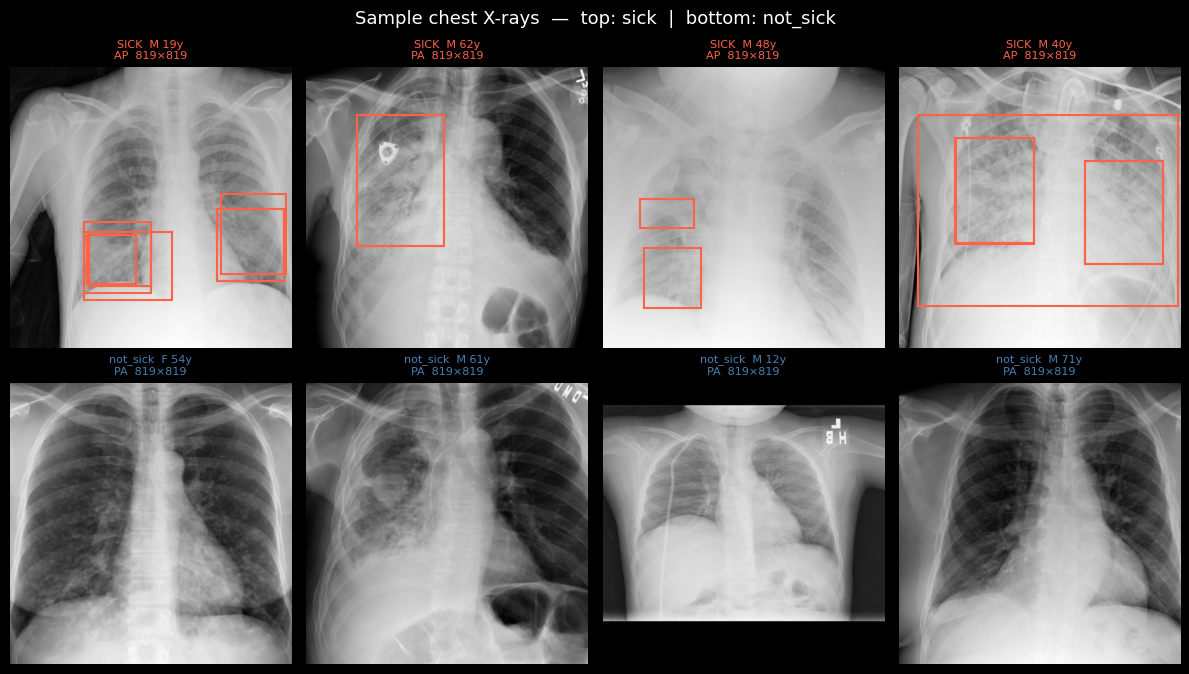

In [2]:
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

# ── Label & demographics summary ────────────────────────────────────────
print(f"Total images : {len(df)}")
print(f"  sick (1)   : {(df.label == 1).sum()} ({(df.label == 1).mean():.1%})")
print(f"  not_sick(0): {(df.label == 0).sum()} ({(df.label == 0).mean():.1%})")
print()
print("Patient sex distribution:")
print(df.groupby('patient_sex')['label'].value_counts().unstack(fill_value=0).to_string())
print()
print(f"Patient age — mean: {df.patient_age.mean():.1f}  "
      f"median: {df.patient_age.median():.0f}  "
      f"min: {df.patient_age.min()}  max: {df.patient_age.max()}")
print(f"View position: {df.view_position.value_counts().to_dict()}")
print()

# ── DICOM metadata for one example ──────────────────────────────────────
sample_path = df.iloc[0]['dicom_path']
ds = pydicom.dcmread(sample_path)
meta_fields = [
    'PatientID', 'PatientAge', 'PatientSex', 'Modality', 'ViewPosition',
    'Rows', 'Columns', 'BitsStored', 'PhotometricInterpretation',
    'RescaleIntercept', 'RescaleSlope',
]

print("DICOM metadata (first image):")
for field in meta_fields:
    print(f"  {field:<30} {getattr(ds, field, 'N/A')}")
print(f"  {'pixel_array.shape':<30} {ds.pixel_array.shape}")
print(f"  {'pixel_array.dtype':<30} {ds.pixel_array.dtype}")
print()

# ── Visualise sample images with bounding boxes ──────────────────────────
N_COLS = 4
samples = pd.concat([
    df[df.label == 1].sample(N_COLS, random_state=0),
    df[df.label == 0].sample(N_COLS, random_state=0),
])

fig, axes = plt.subplots(2, N_COLS, figsize=(N_COLS * 3, 7))
fig.suptitle("Sample chest X-rays  —  top: sick  |  bottom: not_sick", fontsize=13)

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    ds = pydicom.dcmread(row['dicom_path'])
    arr = ds.pixel_array.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)

    # center crop (matches load_dicom pipeline)
    h, w = arr.shape
    ch, cw = int(h * CROP_FRAC), int(w * CROP_FRAC)
    y0, x0 = (h - ch) // 2, (w - cw) // 2
    arr = arr[y0:y0+ch, x0:x0+cw]

    ax.imshow(arr, cmap='gray', aspect='equal')
    label_str = 'SICK' if row.label == 1 else 'not_sick'
    color = 'tomato' if row.label == 1 else 'steelblue'
    ax.set_title(
        f"{label_str}  {row.patient_sex} {int(row.patient_age)}y\n"
        f"{row.view_position}  {arr.shape[0]}×{arr.shape[1]}",
        fontsize=8, color=color,
    )
    ax.axis('off')

    # overlay bounding boxes — offset by crop origin (x0, y0)
    boxes = json.loads(row['bboxes'])
    for b in boxes:
        ax.add_patch(Rectangle(
            (b['x'] - x0, b['y'] - y0), b['width'], b['height'],
            linewidth=1.5, edgecolor='tomato', facecolor='none',
        ))

plt.tight_layout()
plt.show()


In [3]:

def load_dicom(path, size=IMG_SIZE, crop_frac=CROP_FRAC):
    ds = pydicom.dcmread(path)
    arr = ds.pixel_array.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    # center crop — removes border text/watermarks
    h, w = arr.shape
    ch, cw = int(h * crop_frac), int(w * crop_frac)
    y0, x0 = (h - ch) // 2, (w - cw) // 2
    arr = arr[y0:y0+ch, x0:x0+cw]
    # resize and flatten
    img = Image.fromarray((arr * 255).astype(np.uint8)).resize(size)
    return np.array(img).flatten()

# NOTE: delete data/split_cache.npz whenever CROP_FRAC changes — the cache
# stores flattened pixels and will be stale if the crop parameters differ.
if os.path.exists(CACHE_FILE):
    print(f"Loading split from cache: {CACHE_FILE}")
    print(f"  (cached with CROP_FRAC={CROP_FRAC} — delete cache if this changed)")
    cache = np.load(CACHE_FILE)
    X_train, X_test, y_train, y_test = cache["X_train"], cache["X_test"], cache["y_train"], cache["y_test"]
else:
    df = pd.read_csv(LABELS_CSV)
    print(f"Total images: {len(df)}  |  sick: {(df.label==1).sum()}  |  not_sick: {(df.label==0).sum()}")
    print(f"CROP_FRAC={CROP_FRAC}  IMG_SIZE={IMG_SIZE}")

    print("Loading images...")
    X = np.array([load_dicom(p) for p in df["dicom_path"]])
    y = df["label"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    np.savez_compressed(CACHE_FILE, X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
    print(f"Split cached to: {CACHE_FILE}")

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")


Total images: 29916  |  sick: 9247  |  not_sick: 20669
CROP_FRAC=0.8  IMG_SIZE=(64, 64)
Loading images...
Split cached to: data/split_cache.npz
X_train: (23932, 4096)  |  X_test: (5984, 4096)


In [4]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import ADASYN
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import Normalizer
from imblearn.over_sampling import SMOTE

memory = mkdtemp()
pipeline = Pipeline([
    ('normalizer', Normalizer()),
    ('pca', PCA(n_components=0.95)),
    ('smt', SMOTE()),
    ('knn', KNeighborsClassifier(n_jobs=-1)),
], memory=memory)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.61      0.71      4134
           1       0.47      0.77      0.59      1850

    accuracy                           0.66      5984
   macro avg       0.66      0.69      0.65      5984
weighted avg       0.74      0.66      0.67      5984



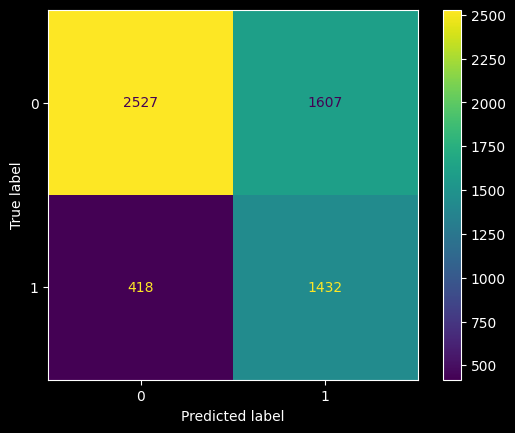

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

# CNN

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

model = models.Sequential([
    Input(shape=(64, 64, 1)),

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid'),   # binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,141,505 (4.35 MB)

 Trainable params: 1,141,505 (4.35 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Reshape flat vectors → (N, 64, 64, 1) and normalise to [0, 1]
X_tr = X_train.reshape(-1, 64, 64, 1).astype('float32') / 255.0
X_te = X_test.reshape(-1, 64, 64, 1).astype('float32') / 255.0

history = model.fit(
    X_tr, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)

# Evaluate on held-out test set
y_prob = model.predict(X_te, batch_size=64).squeeze()
y_pred_cnn = (y_prob >= 0.5).astype(int)
print(classification_report(y_test, y_pred_cnn, target_names=['not_sick', 'sick']))

Epoch 1/10


W0000 00:00:1773408328.590009  153903 cpu_allocator_impl.cc:82] Allocation of 352878592 exceeds 10% of free system memory.


337/337 ━━━━━━━━━━━━━━━━━━━━ 71s 206ms/step - accuracy: 0.7366 - loss: 0.5275 - val_accuracy: 0.7456 - val_loss: 0.5186
Epoch 2/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 69s 206ms/step - accuracy: 0.7612 - loss: 0.4986 - val_accuracy: 0.7594 - val_loss: 0.4906
Epoch 3/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 72s 212ms/step - accuracy: 0.7693 - loss: 0.4863 - val_accuracy: 0.7652 - val_loss: 0.4852
Epoch 4/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 74s 219ms/step - accuracy: 0.7747 - loss: 0.4756 - val_accuracy: 0.7644 - val_loss: 0.4893
Epoch 5/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 75s 222ms/step - accuracy: 0.7772 - loss: 0.4709 - val_accuracy: 0.7669 - val_loss: 0.4868
Epoch 6/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 73s 216ms/step - accuracy: 0.7809 - loss: 0.4645 - val_accuracy: 0.7711 - val_loss: 0.4748
Epoch 7/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 74s 220ms/step - accuracy: 0.7813 - loss: 0.4601 - val_accuracy: 0.7698 - val_loss: 0.4778
Epoch 8/10
337/337 ━━━━━━━━━━━━━━━━━━━━ 73s 217ms/step - accuracy: 0.7856 - loss: 0.4547 - val

W0000 00:00:1773409075.460883  153903 cpu_allocator_impl.cc:82] Allocation of 98041856 exceeds 10% of free system memory.


94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step
              precision    recall  f1-score   support

    not_sick       0.81      0.89      0.85      4134
        sick       0.69      0.54      0.61      1850

    accuracy                           0.78      5984
   macro avg       0.75      0.72      0.73      5984
weighted avg       0.78      0.78      0.78      5984



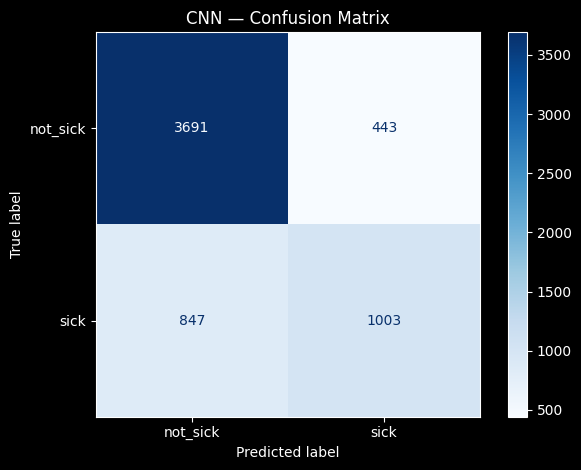

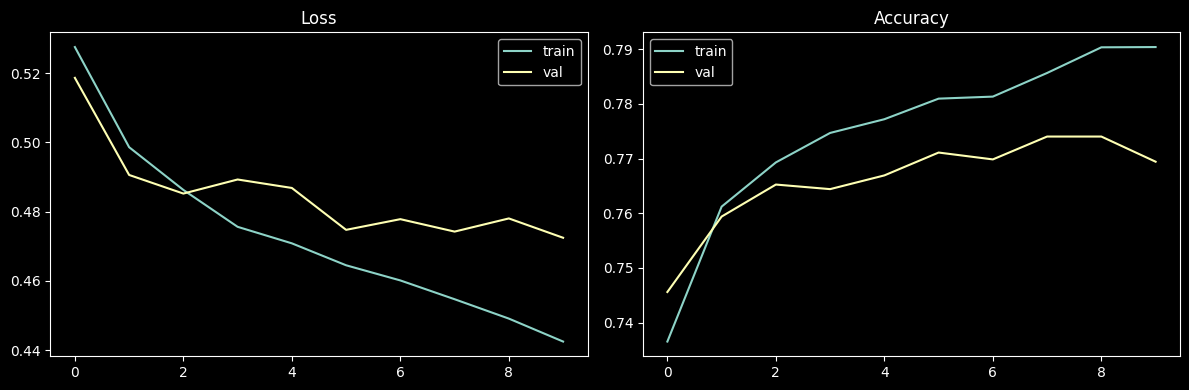

In [10]:
cm = confusion_matrix(y_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(cm, display_labels=['not_sick', 'sick'])
disp.plot(cmap='Blues')
plt.title('CNN — Confusion Matrix')
plt.tight_layout()
plt.show()

# Learning curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss')
ax1.legend()
ax2.plot(history.history['accuracy'], label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('Accuracy')
ax2.legend()
plt.tight_layout()
plt.show()